In [71]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [72]:
root = '/media/sunr/C40AA1B70AA1A740/data/InfoInteg/data_newDeconv'
mname, datexp, blk = 'VG29', '2025_10_10', '2'

In [73]:
from scipy.stats import zscore

beh = np.load(os.path.join(root, 'beh', 'Beh_sup_train1_before_learning.npy'), allow_pickle=1).item()[f'{mname}_{datexp}_{blk}']
print(beh['ft'].shape)  # (frames, )
print(beh.keys())

'''
spks = np.load(os.path.join(root, 'spk', f'{mname}_{datexp}_{blk}_neural_data.npy'), allow_pickle=1).item()['spks']
spks = np.vstack(spks)  
print(f'Loaded {mname}_{datexp}_{blk} spks with shape {spks.shape}') # shape[0] should be (neurons, frame)
nfr = spks.shape[1]
spks = spks[:, beh['istim'][:nfr] >= 2]
spks = zscore(spks, axis=1)
print(f'aligned spks shape: {spks.shape}')
'''

(17724,)
dict_keys(['ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_GraySpc', 'ft_CorrSpc', 'istim', 'ntrials', 'stim_id', 'UniqWalls', 'WallName', 'RewPos', 'SoundPos', 'ft', 'ft_RunSpeed', 'ft_Pos', 'ft_PosCum', 'ft_move', 'ft_isMoving', 'ft_WallID', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'LickTime', 'LickPos', 'Lick_wallName', 'LickTrind'])


"\nspks = np.load(os.path.join(root, 'spk', f'{mname}_{datexp}_{blk}_neural_data.npy'), allow_pickle=1).item()['spks']\nspks = np.vstack(spks)  \nprint(f'Loaded {mname}_{datexp}_{blk} spks with shape {spks.shape}') # shape[0] should be (neurons, frame)\nnfr = spks.shape[1]\nspks = spks[:, beh['istim'][:nfr] >= 2]\nspks = zscore(spks, axis=1)\nprint(f'aligned spks shape: {spks.shape}')\n"

In [74]:
# @title Load behavioral data
stim_id = beh['stim_id'] # 0:circle1, 1:circle2, 2:leaf1, 3:leaf2, 4:leaf3
ntrials, uniqW, WallN = beh['ntrials'], beh['UniqWalls'], beh['WallName']
SoundPos = beh['SoundPos']

lick_fr = beh['LickFr'] # frame with lick
LickPos = beh['LickPos'] # position with lick
LickTrind = beh['LickTrind']
#cue_fr = beh['SoundFr'] # frame with cue
stim_fr = beh['ft_WallID'] # trial stimulus of each frame
pos_fr = beh['ft_Pos'] # position of each frame inside corridor
cum_pos_fr = beh['ft_PosCum']
VR_move = beh['ft_move']>0 # frames with virtual scene moving

name_stim1 = uniqW[stim_id==2][0] # name of stimulus 1; rewarded stimulus (leaf1) for supervised experiment
name_stim2 = uniqW[stim_id==0][0] # name of stimulus 2; non-rewarded stimulus (circle1) for supervised experiment
name_mstim1 = uniqW[stim_id==3][0] # name of stimulus 1; rewarded stimulus (leaf2) for supervised experiment
name_mstim2 = uniqW[stim_id==1][0] # name of stimulus 2; non-rewarded stimulus (circle2) for supervised experiment
stim1_tr = WallN==name_stim1
stim2_tr = WallN==name_stim2
mstim1_tr = WallN==name_mstim1
mstim2_tr = WallN==name_mstim2

# get index of frame within stimulus 1 (0-40 is within texture area, 40-60 is gray space)
stim1_idx = (stim_fr==name_stim1) & (pos_fr<0.4)
stim2_idx = (stim_fr==name_stim2) & (pos_fr<0.4)
mstim1_idx = (stim_fr==name_mstim1) & (pos_fr<0.4)
mstim2_idx = (stim_fr==name_mstim2) & (pos_fr<0.4)
# get index of frame within gray space after stimulus 1
gray_idx = ((stim_fr==name_stim1) | (stim_fr==name_stim2)) | (stim_fr==name_mstim1) | (stim_fr==name_mstim2) & (pos_fr>=0.4)

## Licks

[  1.   2.   2. ... 488. 488. 488.]


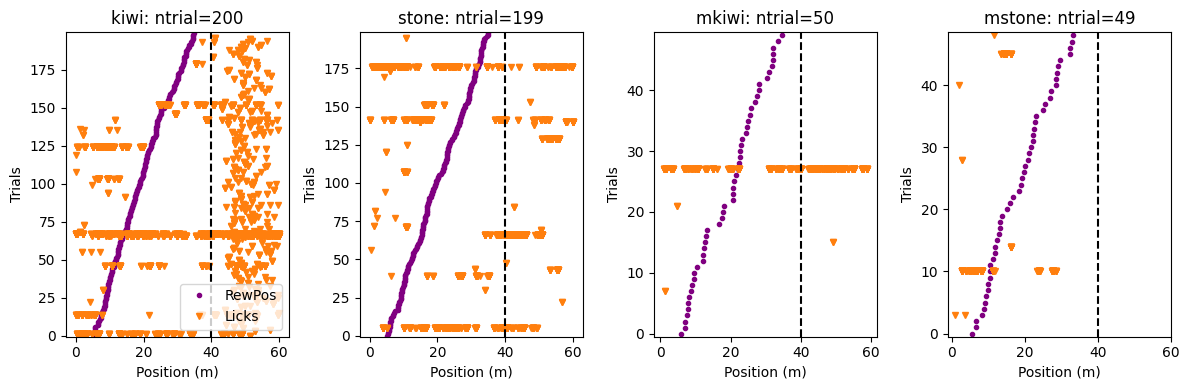

In [75]:
stims = [name_stim1, name_stim2, name_mstim1, name_mstim2]
stim_trs = [stim1_tr, stim2_tr, mstim1_tr, mstim2_tr]
LickTr = LickTrind - 1
print(LickTrind)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    stim_tr = stim_trs[i]
    tr_idx = np.flatnonzero(stim_tr) 

    rew_pos = SoundPos[stim_tr]
    sort_ind = np.argsort(rew_pos, 0)
    tr_idx_sorted = tr_idx[sort_ind]
    axes[i].plot(rew_pos[sort_ind], np.arange(tr_idx_sorted.size), marker='.', 
                 color='purple', ls='None', label=('RewPos' if i == 0 else '_nolegend_'))

    labeled_lick = False
    for row, tr in enumerate(tr_idx_sorted):
        m = (LickTr == tr)
        if np.any(m):
            label = 'Licks' if not labeled_lick else '_nolegend_'
            axes[i].plot(LickPos[m], np.full(m.sum(), row), 'v', color='tab:orange',
                         ms=5, alpha=1, label=label)
            labeled_lick = True

    axes[i].axvline(x=0.4, color='k', ls='--')
    axes[i].set_ylabel('Trials')
    axes[i].set_ylim([-0.5, tr_idx_sorted.size - 0.5])
    axes[i].set_xticks([0, 0.2, 0.4, 0.6])
    axes[i].set_xticklabels([0, 20, 40, 60])
    axes[i].set_xlabel('Position (m)')
    axes[i].set_title(f'{stims[i]}: ntrial={tr_idx_sorted.size}')

axes[0].legend(loc='lower right')
plt.tight_layout()
plt.show()

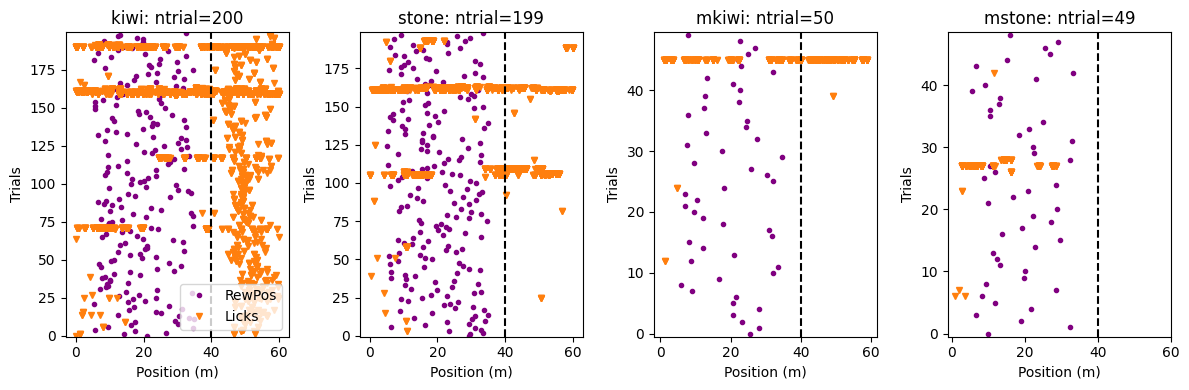

In [76]:
stims = [name_stim1, name_stim2, name_mstim1, name_mstim2]
stim_trs = [stim1_tr, stim2_tr, mstim1_tr, mstim2_tr]
LickTr = LickTrind - 1

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    stim_tr = stim_trs[i]
    tr_idx = np.flatnonzero(stim_tr) 

    rew_pos = SoundPos[stim_tr]
    tr_idx_sorted = tr_idx
    axes[i].plot(rew_pos, np.arange(tr_idx_sorted.size), marker='.', 
                 color='purple', ls='None', label=('RewPos' if i == 0 else '_nolegend_'))

    labeled_lick = False
    for row, tr in enumerate(tr_idx_sorted):
        m = (LickTr == tr)
        if np.any(m):
            label = 'Licks' if not labeled_lick else '_nolegend_'
            axes[i].plot(LickPos[m], np.full(m.sum(), row), 'v', color='tab:orange',
                         ms=5, alpha=1, label=label)
            labeled_lick = True

    axes[i].axvline(x=0.4, color='k', ls='--')
    axes[i].set_ylabel('Trials')
    axes[i].set_ylim([-0.5, tr_idx_sorted.size - 0.5])
    axes[i].set_xticks([0, 0.2, 0.4, 0.6])
    axes[i].set_xticklabels([0, 20, 40, 60])
    axes[i].set_xlabel('Position (m)')
    axes[i].set_title(f'{stims[i]}: ntrial={tr_idx_sorted.size}')

axes[0].legend(loc='lower right')
plt.tight_layout()
plt.show()